In [3]:
"""
Python DA Assignment 2 - Data Visualization
Dataset: seaborn's built-in 'taxis' dataset
"""


# ============================================================
# 0) IMPORTS
# ============================================================
import pandas as pd                 # for DataFrame operations (groupby, fillna, dropna, etc.)
import matplotlib.pyplot as plt      # for Matplotlib/Pandas-based plots (line, bar, pie, hist, box)
import seaborn as sns                # for the dataset itself, and Seaborn-based plots


# ============================================================
# 1) LOADING THE TAXIS DATASET
# ============================================================
df = sns.load_dataset("taxis")       # loads the sample 'taxis' dataset as a pandas DataFrame
print(df.head())                     # sanity check: view the first 5 rows to confirm it loaded


               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [4]:
# ============================================================
# 2) HANDLING MISSING VALUES
# ============================================================

# --- 2a. Check for missing values ---
print("\nMissing values per column:")
print(df.isnull().sum())             # counts missing values in every column so we know what needs fixing
# In this dataset, the columns with missing data are:
# payment, pickup_zone, dropoff_zone, pickup_borough, dropoff_borough (all categorical/text)

# --- 2b. Impute based on column type ---
# Numerical columns (distance, fare, tip, tolls, total) have NO missing values here,
# but the general approach for numeric columns would be:
#   df["numeric_col"] = df["numeric_col"].fillna(df["numeric_col"].median())
# Median is preferred over mean when the column may contain outliers (fares can spike).

# Categorical columns DO have missing values, so we fill them with the mode
# (the most frequently occurring category), since mean/median don't apply to text data.
categorical_cols = ["payment", "pickup_zone", "dropoff_zone",
                     "pickup_borough", "dropoff_borough"]

for col in categorical_cols:                         # loop through each categorical column
    mode_value = df[col].mode()[0]                    # mode() returns a Series; [0] grabs the top value
    df[col] = df[col].fillna(mode_value)              # replace NaNs in that column with its mode

# --- 2c. Drop rows for critical columns that can't be reasonably imputed ---
# Guessing a pickup/dropoff timestamp or fare amount would distort the analysis,
# so if any rows still had missing values in these truly critical numeric/time columns,
# we would drop them outright instead of guessing:
critical_cols = ["pickup", "dropoff", "fare", "distance"]
df = df.dropna(subset=critical_cols)                 # removes rows missing any critical value (none here, but kept for completeness)

print("\nMissing values after cleaning:")
print(df.isnull().sum())                              # confirm everything is now 0



Missing values per column:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

Missing values after cleaning:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


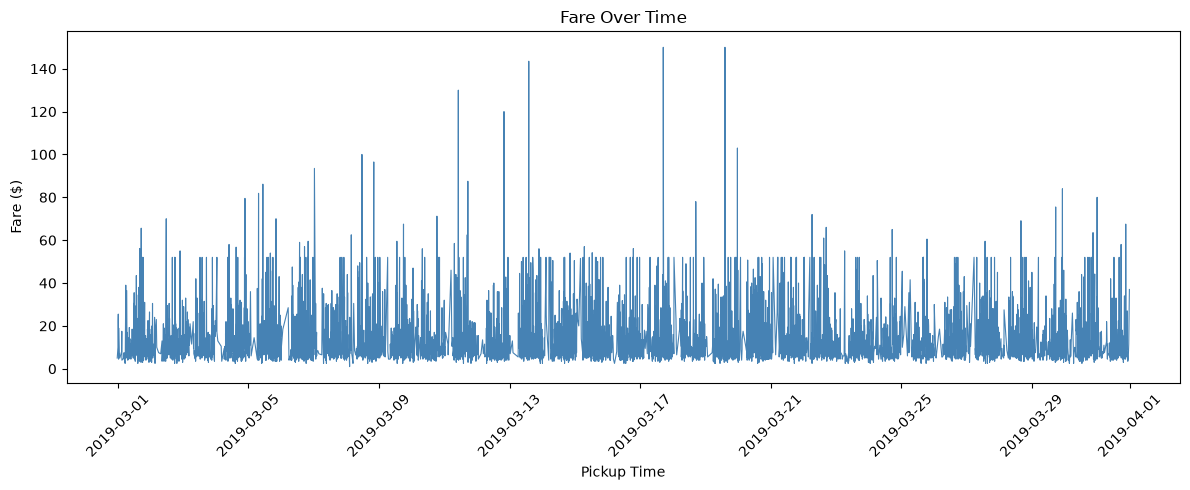

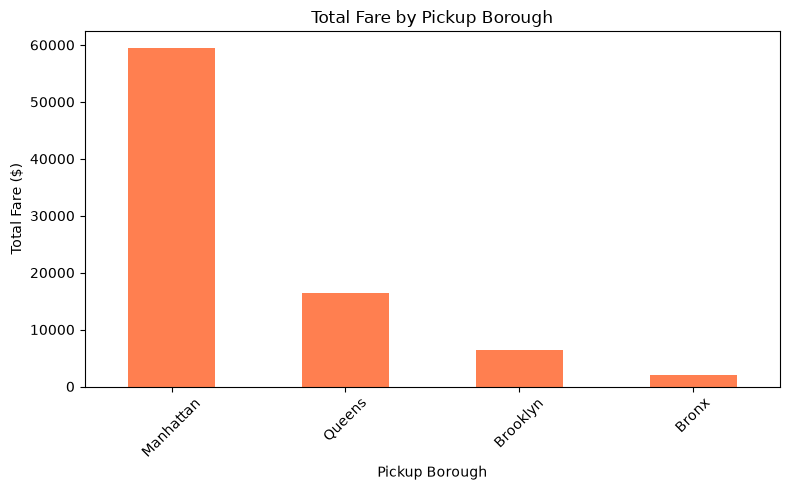

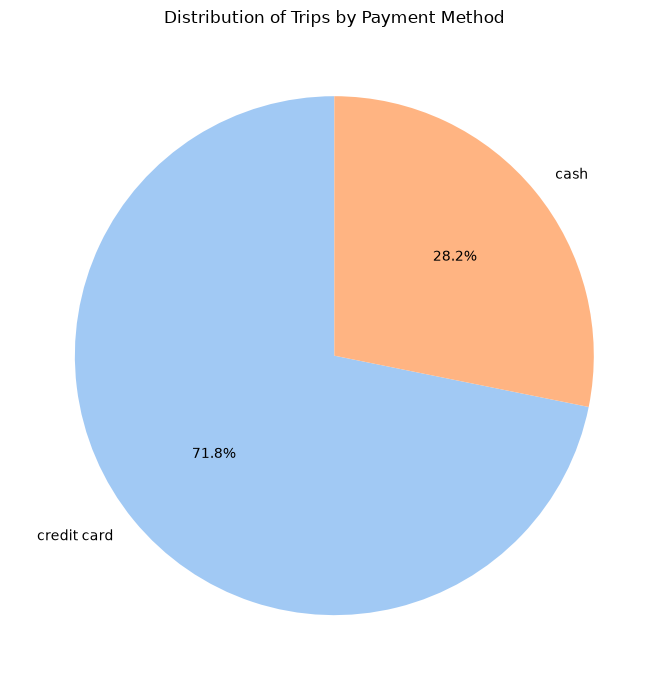

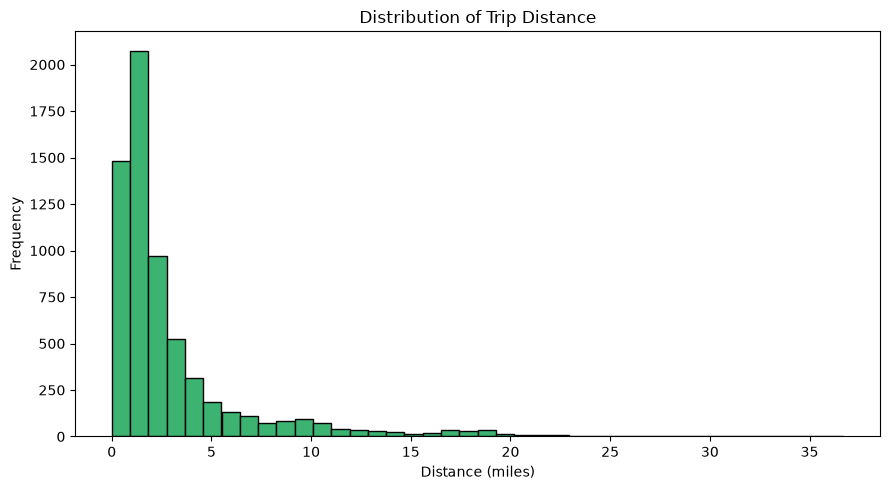

<Figure size 900x500 with 0 Axes>

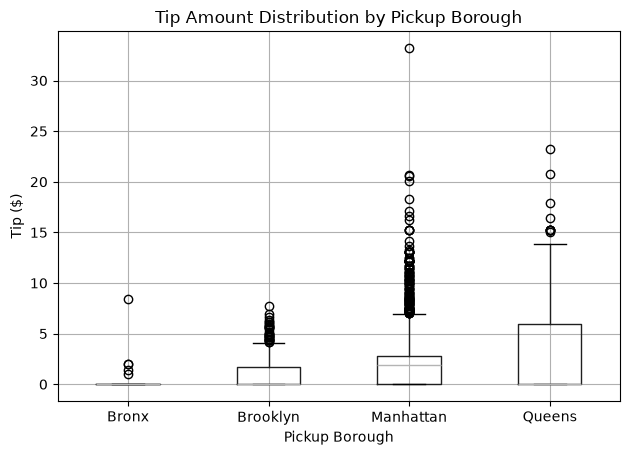

In [5]:
# ============================================================
# 3) VISUALIZATIONS USING MATPLOTLIB / PANDAS PLOT
# ============================================================

# ---------- Line Chart: fare over time ----------
df["pickup"] = pd.to_datetime(df["pickup"])           # convert pickup column from text/object to real datetime
df_time_sorted = df.sort_values("pickup")             # sort chronologically so the line moves left-to-right sensibly

plt.figure(figsize=(12, 5))                           # create a new figure, sized for readability
plt.plot(df_time_sorted["pickup"], df_time_sorted["fare"],
         color="steelblue", linewidth=0.8)            # plot pickup time (x) vs fare (y)
plt.title("Fare Over Time")                           # chart title
plt.xlabel("Pickup Time")                             # x-axis label
plt.ylabel("Fare ($)")                                # y-axis label
plt.xticks(rotation=45)                               # rotate date labels so they don't overlap
plt.tight_layout()                                    # auto-adjust spacing so labels aren't cut off
plt.show()                                             # render the plot

# ---------- Bar Chart: total fare per pickup_borough ----------
borough_fare = df.groupby("pickup_borough")["fare"].sum()   # group rows by borough, sum fare within each group

plt.figure(figsize=(8, 5))
borough_fare.sort_values(ascending=False).plot(kind="bar", color="coral")  # Pandas' built-in .plot() draws the bar chart
plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------- Pie Chart: distribution of payment methods ----------
payment_counts = df["payment"].value_counts()         # counts how many trips used each payment method

plt.figure(figsize=(7, 7))
plt.pie(payment_counts,
        labels=payment_counts.index,                  # slice labels = payment method names
        autopct="%1.1f%%",                            # show percentage on each slice, 1 decimal place
        startangle=90,                                # rotate so the first slice starts at the top
        colors=sns.color_palette("pastel"))           # use a pleasant color palette
plt.title("Distribution of Trips by Payment Method")
plt.tight_layout()
plt.show()

# ---------- Histogram: distribution of distance ----------
plt.figure(figsize=(9, 5))
plt.hist(df["distance"], bins=40, color="mediumseagreen", edgecolor="black")  # 40 bins for finer granularity
plt.title("Distribution of Trip Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ---------- Box Plot: tip amount by pickup_borough ----------
plt.figure(figsize=(9, 5))
df.boxplot(column="tip", by="pickup_borough")         # Pandas' boxplot: numeric column grouped by a category
plt.title("Tip Amount Distribution by Pickup Borough")
plt.suptitle("")                                      # removes the automatic default subtitle Pandas adds
plt.xlabel("Pickup Borough")
plt.ylabel("Tip ($)")
plt.tight_layout()
plt.show()


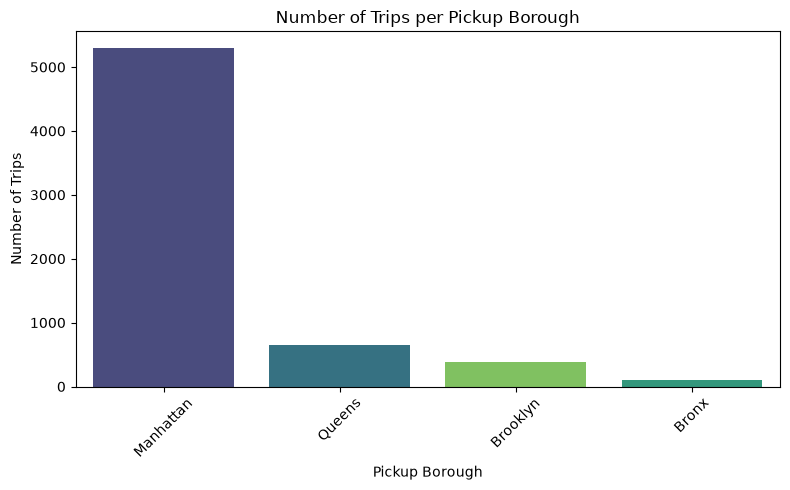

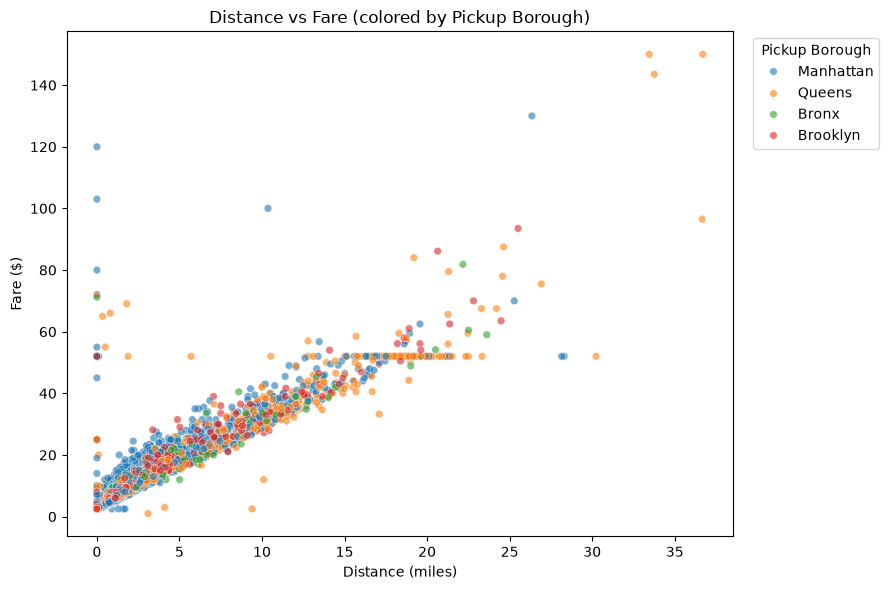

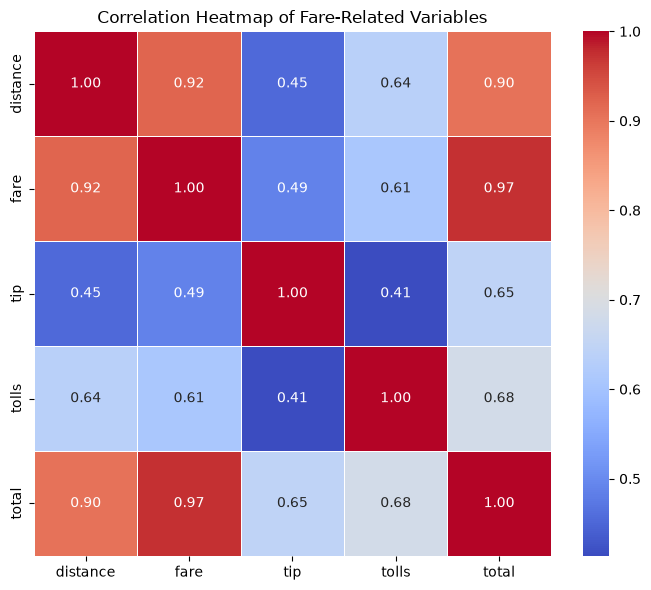

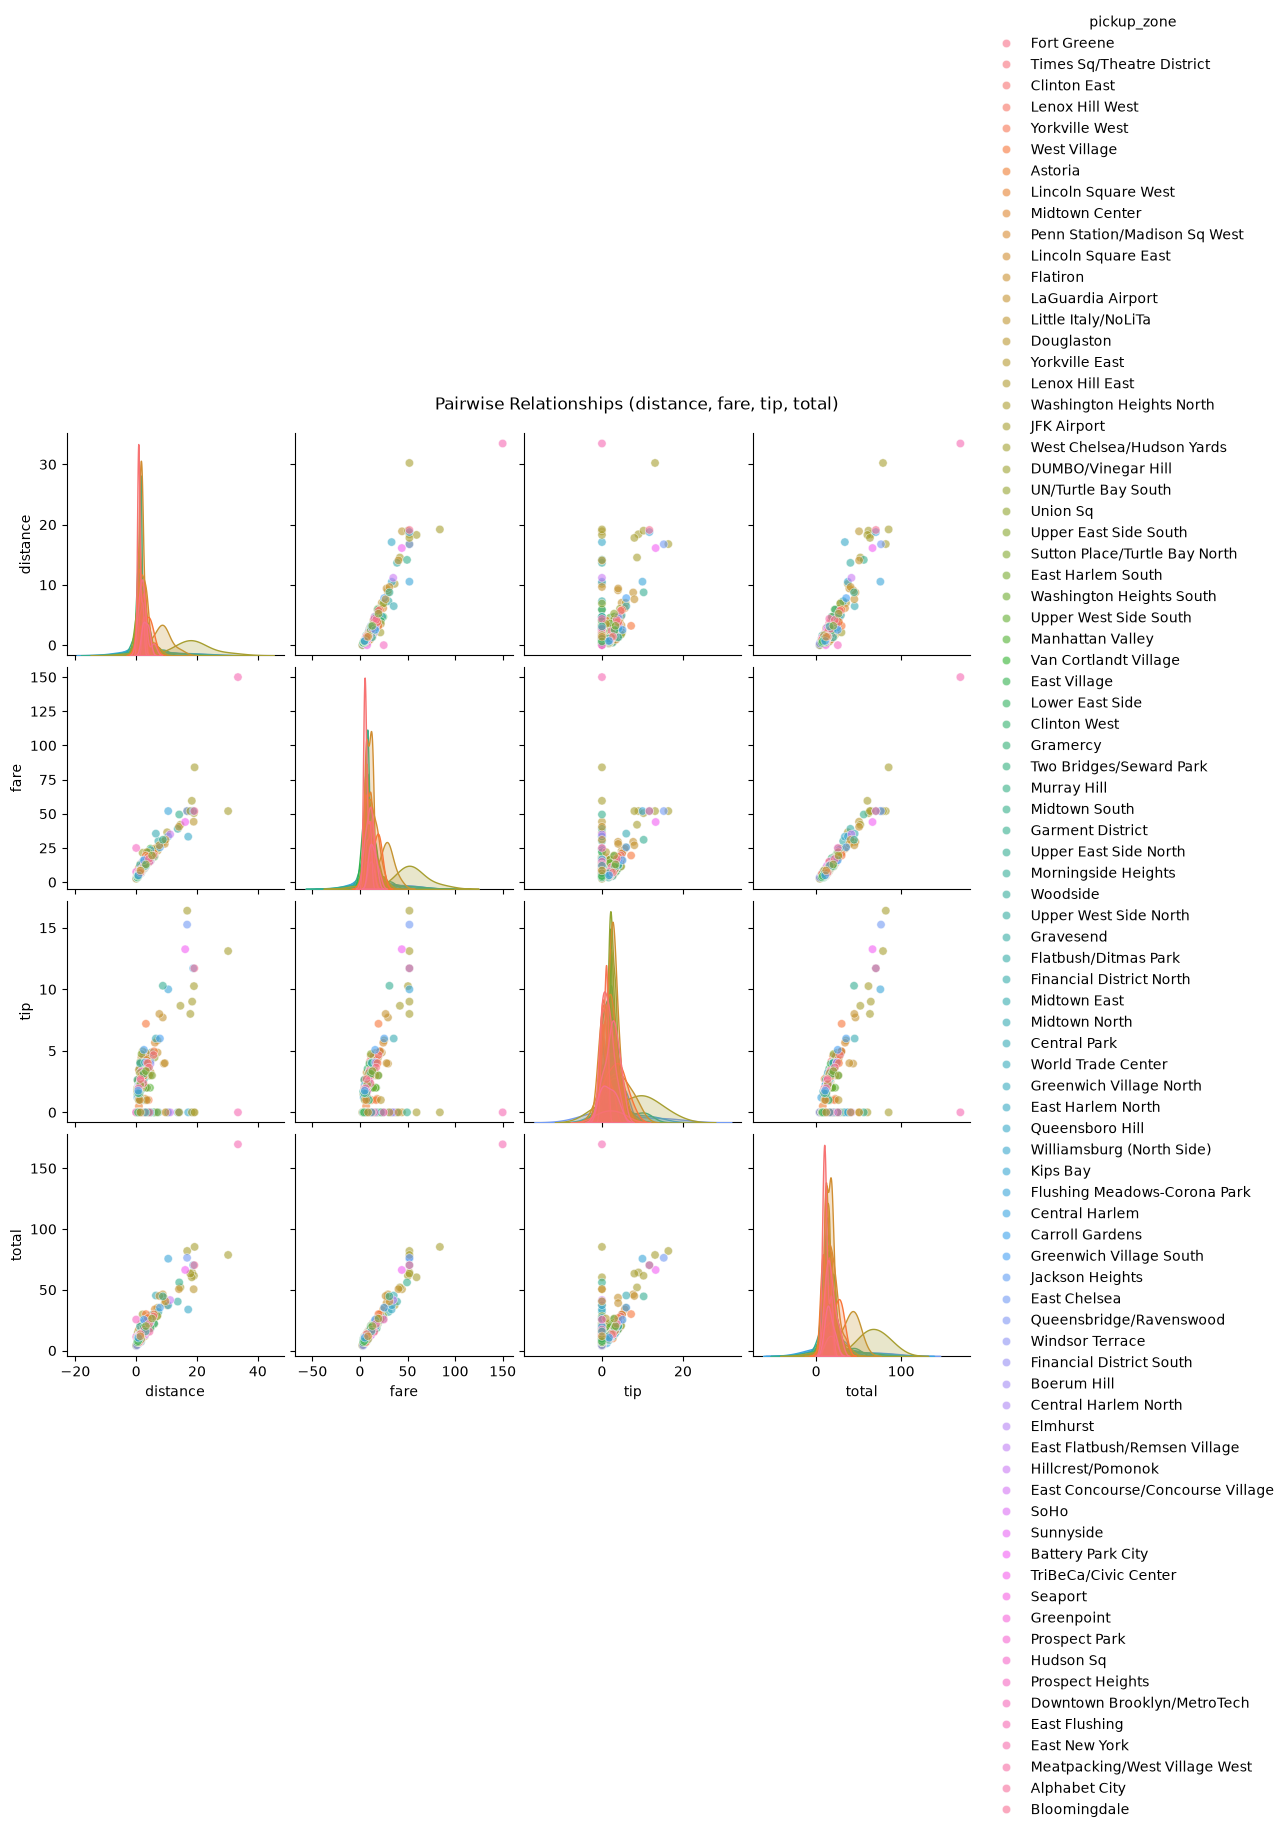

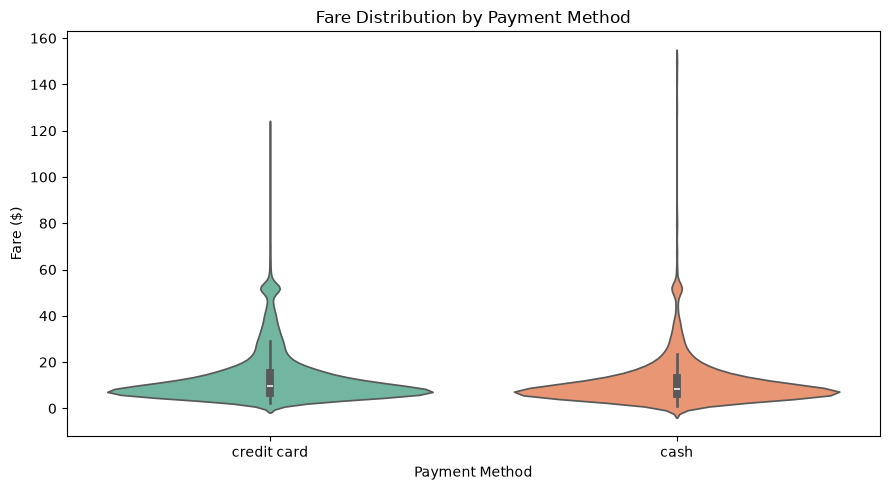

In [6]:
# ============================================================
# VISUALIZATIONS USING SEABORN
# ============================================================

# ---------- Count Plot: number of trips per pickup_borough ----------
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="pickup_borough",
              order=df["pickup_borough"].value_counts().index,  # order bars from most to least trips
              hue="pickup_borough", palette="viridis", legend=False)  # hue+legend=False keeps per-bar coloring without a redundant legend
plt.title("Number of Trips per Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------- Scatter Plot: distance vs fare, colored by borough ----------
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="distance", y="fare",
                 hue="pickup_borough",                 # color-codes points by borough
                 alpha=0.6, s=30)                       # transparency + point size for readability with many points
plt.title("Distance vs Fare (colored by Pickup Borough)")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.legend(title="Pickup Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------- Heatmap: correlation between numerical variables ----------
numeric_cols = ["distance", "fare", "tip", "tolls", "total"]
corr_matrix = df[numeric_cols].corr()                  # computes pairwise Pearson correlation coefficients

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)  # annot=True prints the numbers on each cell
plt.title("Correlation Heatmap of Fare-Related Variables")
plt.tight_layout()
plt.show()

# ---------- Pair Plot: pairwise relationships ----------
# Note: pickup_zone has ~190 unique values, so using it as `hue` produces an unreadable
# legend. We take a random sample of rows purely so the plot renders in reasonable time;
# for a cleaner, more interpretable legend, `hue="pickup_borough"` (only 6 categories)
# is a better practical substitute if your instructor allows it.
sample_df = df[["distance", "fare", "tip", "total", "pickup_zone"]].sample(300, random_state=1)

sns.pairplot(sample_df, hue="pickup_zone", plot_kws={"alpha": 0.6}, palette="husl")
plt.suptitle("Pairwise Relationships (distance, fare, tip, total)", y=1.02)
plt.show()

# ---------- Violin Plot: fare distribution by payment method ----------
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x="payment", y="fare", hue="payment", palette="Set2", legend=False)
plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare ($)")
plt.tight_layout()
plt.show()